# TripAdvisor Information Retrieval Project
**Project 1 - Information Retrieval & NLP**

Alvaro SERERO, Leo WINTER

ESILV A4 DIA6

## 1. Setup & Imports

Library installation for **Google Colab** ( or **Colab extension** on VS Code)

In [ ]:
!pip install rank_bm25 spacy sentence-transformers
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Import of library that we will use in this project

In [ ]:
import ast
import gc
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Load English spaCy model (we only use English reviews)
nlp = spacy.load("en_core_web_sm")

Global variable initialization

In [ ]:
DATA_PATH    = Path("TripAdvisorTrainingDataProject1")
RANDOM_STATE = 42

# Column used to evaluate our dataset with level 1 evaluation
LABEL_COLUMNS   = ["typeR"]

# Columns that we our model need in the review dataset
REVIEWS_COLUMNS = ["idplace", "review", "langue"]

# Column that we need to test our model in the trip advisor dataset
META_COLS = ["id", "typeR", "activiteSubCategorie", "activiteSubType",
             "restaurantType", "restaurantTypeCuisine", "priceRange"]

# The maximum number of review by place that we use to train our model
MAX_REVIEWS_PER_PLACE = 50  # set to None to use all reviews

## 2. Load Data

For **Colab extension** (or **Google Colab**) to get to the csv folder in google drive

In [29]:
from google.colab import drive

# The path in your drive to the csv file
DRIVE_PATH = Path("/content/drive/MyDrive/Colab Notebooks")
drive.mount('/content/drive/')

DATA_PATH    = DRIVE_PATH / DATA_PATH

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


We load the dataset

In [ ]:
# We load the Dataset and we put them into pandas DataFrame
attraction_sub_categorie = pd.read_csv(DATA_PATH / "AttractionSubCategorie.csv")
attraction_sub_type = pd.read_csv(DATA_PATH / "AttractionSubType.csv")
cuisine_df = pd.read_csv(DATA_PATH / "cuisine.csv")
dietary_restrictions_df = pd.read_csv(DATA_PATH / "dietary_restrictions.csv")
restaurant_type_df = pd.read_csv(DATA_PATH / "restaurantType.csv")
reviews = pd.read_csv(DATA_PATH / "reviews83325.csv", low_memory=False) 
trip_advisor = pd.read_csv(DATA_PATH / "Tripadvisor.csv", low_memory=False) 


print(f"reviews: {reviews.shape}")
print(f"trip_advisor: {trip_advisor.shape}")
print("\ntrip_advisor columns:", trip_advisor.columns.tolist())

reviews: (340385, 21)
trip_advisor: (3761, 60)

trip_advisor columns: ['id', 'idTrip', 'fromId', 'nom', 'url', 'rating', 'nbAvis', 'nbAvisRecupere', 'latitude', 'longitude', 'typeR', 'adresse', 'priceRange', 'closed', 'hotelType', 'hotelStyle', 'hotelStars', 'hotelRoomNumber', 'hotelNoteEmplacement', 'hotelNoteProprete', 'hotelNoteService', 'HotelNoteQualitePrix', 'hoteldistance', 'hotelbearing', 'restaurantTypeCuisine', 'restaurantDietaryRestrictions', 'restaurantMeals', 'restaurantFeatures', 'restaurantNoteCuisine', 'restaurantNoteService', 'restaurantNoteQualitePrix', 'restaurantNoteAmbiance', 'activiteType', 'activiteSubCategorie', 'activiteSubType', 'website', 'nbScanReview', 'dateLastScanReviews', 'shape_gid', 'gadm36_gid', 'hotelprice', 'hotelBookingID', 'restaurantSubcategory', 'restaurantType', 'ap_additional_info', 'ap_age_band_list', 'ap_attraction_ids', 'ap_booking_question_list', 'ap_bubble_rating_integer', 'ap_duration', 'ap_exclusion', 'ap_inclusions', 'ap_introduction',

## 3. Exploratory Data Analysis

We check the distribution of the metadata for our Level 1 evaluation   

In typeR :  
H = Hotel | R = Restaurant | A = Attraction | AP = Attraction Product

In [ ]:
print("Place type distribution (typeR):")
print(trip_advisor["typeR"].value_counts())

Place type distribution (typeR):
typeR
AP    2669
R      623
A      405
H       64
Name: count, dtype: int64


We check the languages of the reviews

In [ ]:
print("\nReview language distribution (top 10):")
print(reviews["langue"].value_counts(normalize=True).mul(100).round(2).head(10))


Review language distribution (top 10):
langue
en    44.97
fr    29.11
it     6.73
es     6.40
pt     5.73
ru     1.60
de     1.54
ja     1.21
nl     0.83
ko     0.33
Name: proportion, dtype: float64


We create a function to mount the secondary dataset to the main trip_advisor dataset

In [ ]:
def add_name_from_id(dataset_input, input_column_name, dataset_id):
    """
        Transform id into names for the columns in parameters if its corresponding dataset exists
    """
    if input_column_name not in dataset_input.columns:
        print(f"Column {input_column_name} not found")
        return dataset_input

    # We create a copy to not modify our original dataset
    dataset_id = dataset_id.copy()
    # We creates a set from the secondary dataset containing the id and names
    dataset_id["id"] = dataset_id["id"].astype(str)
    mapping = dataset_id.set_index("id")["name"].to_dict()

    def id_to_name(id_string):
        if pd.isna(id_string):
            return np.nan
        
        id_list = str(id_string).split(",") 
        return ", ".join(mapping.get(name.strip(), "Unknown") for name in id_list)

    # Apply the mapping to the primary dataset with the id
    dataset_input[f"{input_column_name}"] = dataset_input[input_column_name].apply(id_to_name)
    return dataset_input

# We create a copy to not modify our original dataset
trip_advisor_completed= trip_advisor.copy()

# We apply the function to the dataset
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "activiteSubCategorie", attraction_sub_categorie)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "activiteSubType", attraction_sub_type)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantTypeCuisine", cuisine_df)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantDietaryRestrictions", dietary_restrictions_df)
trip_advisor_completed = add_name_from_id(trip_advisor_completed, "restaurantType", restaurant_type_df)

# Since the data from this dataset is added to our new dataset, we delete it to free some memory
del attraction_sub_categorie
del attraction_sub_type
del cuisine_df
del dietary_restrictions_df
del restaurant_type_df
gc.collect()

trip_advisor_completed[["id", "nom", "typeR",
                        "activiteSubCategorie", "restaurantType"]].head(5)

,id,nom,typeR,activiteSubCategorie,restaurantType
0,188467,Place des Vosges,A,Sites touristiques,NaN
1,188468,Rue des Francs Bourgeois,A,Sites touristiques,NaN
2,188470,Village Saint-Paul,A,"Shopping, Sites touristiques, Autre",NaN
3,188471,Au Passe-partout,A,Shopping,NaN
4,188472,Cloître des Billettes,A,Sites touristiques,NaN


We check the repartition of the columns for the evaluation level 2

In [ ]:
print("ActiviteSubCategorie :")
print("     Unique values :",trip_advisor_completed['activiteSubCategorie'].nunique())
print("     Nan values",trip_advisor_completed['activiteSubCategorie'].isna().sum())
print("     Total values :",trip_advisor_completed['activiteSubCategorie'].count())
print("     id type :", trip_advisor_completed['activiteSubCategorie'].dtype)

print("\nActiviteSubType :")
print("     Unique values :",trip_advisor_completed['activiteSubType'].nunique())
print("     Nan values",trip_advisor_completed['activiteSubType'].isna().sum())
print("     Total values :",trip_advisor_completed['activiteSubType'].count())
print("     id type :", trip_advisor_completed['activiteSubType'].dtype)

print("\nRestaurantTypeCuisine :")
print("     Unique values :",trip_advisor_completed['restaurantTypeCuisine'].nunique())
print("     Nan values",trip_advisor_completed['restaurantTypeCuisine'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantTypeCuisine'].count())
print("     id type :", trip_advisor_completed['restaurantTypeCuisine'].dtype)

print("\nRestaurantDietaryRestrictions :")
print("     Unique values :",trip_advisor_completed['restaurantDietaryRestrictions'].nunique())
print("     Nan values",trip_advisor_completed['restaurantDietaryRestrictions'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantDietaryRestrictions'].count())
print("     id type :", trip_advisor_completed['restaurantDietaryRestrictions'].dtype)

print("\nRestaurantType :")
print("     Unique values :",trip_advisor_completed['restaurantType'].nunique())
print("     Nan values",trip_advisor_completed['restaurantType'].isna().sum())
print("     Total values :",trip_advisor_completed['restaurantType'].count())
print("     id type :", trip_advisor_completed['restaurantType'].dtype)

ActiviteSubCategorie :
     Unique values : 45
     Nan values 3356
     Total values : 405
     id type : object

ActiviteSubType :
     Unique values : 124
     Nan values 3356
     Total values : 405
     id type : object

RestaurantTypeCuisine :
     Unique values : 245
     Nan values 3243
     Total values : 518
     id type : object

RestaurantDietaryRestrictions :
     Unique values : 16
     Nan values 3529
     Total values : 232
     id type : object

RestaurantType :
     Unique values : 14
     Nan values 3138
     Total values : 623
     id type : object


## 4. Preprocessing

- Keep English reviews only
- Drop rows with missing reviews
- Lemmatize with spaCy: lowercase, alphabetic tokens only, stopwords removed

In [ ]:
# We take only the review only in english
reviews_english = reviews[reviews["langue"] == "en"][REVIEWS_COLUMNS].copy()
# We removes the Nan review from the dataset
reviews_english = reviews_english.dropna(subset=["review"]).reset_index(drop=True)
print(f"English reviews: {len(reviews_english):,} / {len(reviews):,} total")

English reviews: 153,071 / 340,385 total


0

In [12]:
def clean_text_spacy(texts: list) -> list:
    """
    Lemmatization of a batch of texts using spaCy.
    """
    results = []
    # We use pip to disable the parser and ner module of our spacy model so that our code run faster
    for doc in nlp.pipe(texts, batch_size=256, disable=["parser", "ner"]):
        # We apply lemmatisation and keeps only alphabetic, non-stop tokens longer than 2 characters
        lemmas = [
            t.lemma_.lower()
            for t in doc
            if t.is_alpha and not t.is_stop and len(t) > 2
        ]
        # We put the text together again to have our review
        results.append(" ".join(lemmas))
    return results

# We apply our lemmatisation function to our code
reviews_english["clean_review"] = clean_text_spacy(reviews_english["review"].tolist())

print("Sample input:", reviews_english["review"].iloc[0])
print("Sample output:", reviews_english["clean_review"].iloc[0])

Sample input: Personally I think it is the most beautiful square of Paris. Well maintained and the area around it gives you opportunities to grab a bite to eat as well.
Sample output: personally think beautiful square paris maintain area give opportunity grab bite eat


## 5. Build REVIEW PLACE DATASET

Each line contains all cleaned reviews of a place concatenated.

We also apply a cap to reduce the size imbalance between popular and less popular places.

There's a `MAX_REVIEWS_PER_PLACE = 50` cap to reduce the imbalance between very popular and obscure places.

In [ ]:
def aggregate_reviews(reviews):
    """
    Transform the pandas series into a list and only keep at most 50 reviews
    """
    reviews_texts = reviews["clean_review"].tolist()
    if MAX_REVIEWS_PER_PLACE:
        reviews_texts = reviews_texts[:MAX_REVIEWS_PER_PLACE]
    # Create one string containing the list of reviews
    return " ".join(reviews_texts)

# We create a new dataset where we group our review by place
reviews_place = (
    reviews_english
    .groupby("idplace", group_keys=False)
    .apply(aggregate_reviews, include_groups=False)
    .reset_index()
    .rename(columns={"idplace": "place_id", 0: "reviews"})
)
print(f"Places with more than 1 English review: {len(reviews_place)}")

metadata_colums = [column for column in META_COLS if column in trip_advisor.columns]

# We get our evaluation column into our model dataset
reviews_place = reviews_place.merge(
    trip_advisor[metadata_colums].rename(columns={"id": "place_id"}),
    on="place_id",
    how="left",
)
print(f"After metadata merge: {len(reviews_place)} places")
print(reviews_place["typeR"].value_counts())

Places with more than 1 English review: 1835
After metadata merge: 1835 places
typeR
AP    989
R     538
A     252
H      56
Name: count, dtype: int64


## 6. Train / Test Split

50% **train**: used as train dataset   
50% **test**: used as test dataset for evaluation 

In [ ]:
train_data, test_data = train_test_split(
    reviews_place, test_size=0.5, random_state=RANDOM_STATE, shuffle=True,
    stratify=reviews_place["typeR"],  # ensure balanced type distribution across splits
)
train_data = train_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train size :    {len(train_data)}")
print(f"Test  size : {len(test_data)}")
print("\nTrain type distribution :")
print(train_data["typeR"].value_counts())
print("\nTest type distribution :")
print(test_data["typeR"].value_counts())

Train size :    917
Test  size : 918

Train type distribution :
typeR
AP    494
R     269
A     126
H      28
Name: count, dtype: int64

Test type distribution :
typeR
AP    495
R     269
A     126
H      28
Name: count, dtype: int64


## 7. Baseline Models

### Implementation of the baseline Model: BM25

In [ ]:
# Building BM25 index on test candidates
test_tokenized = [review.split() for review in test_data["reviews"]]
bm25_index = BM25Okapi(test_tokenized)

def retrieve_bm25(review_to_score: str) -> np.ndarray:
    # The function returns the indices ranked with the highest first
    scores = bm25_index.get_scores(review_to_score.split())
    return np.argsort(scores)[::-1]

### Implementation of the TF-IDF with Cosine Similarity

We created a TD-IDF vectorizer and fit it on the training data. Then, we use our model to obtain the result matrix on the train and test data

In [16]:
# Fitting TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True)

# Fit on train data only
tfidf_vectorizer.fit(train_data["reviews"])

# We then use the model on both train and test data to get the test and train matrix
train_matrix = tfidf_vectorizer.transform(train_data["reviews"])  
test_matrix  = tfidf_vectorizer.transform(test_data["reviews"])   

print(f"Train matrix: {train_matrix.shape}")
print(f"Test  matrix: {test_matrix.shape}")

Train matrix: (917, 20000)
Test  matrix: (918, 20000)


We created a get_ranked_indices_batch function that calculate the rank of our matrix by using cosine similarity.  

The function works in batch so that it doesn't treat the entire matrix at one time

In [ ]:
def get_ranked_indices_batch(train_matrix, test_matrix, batch_size: int = 200) -> np.ndarray:
    """
    Function that compute the cosine similarity for every values in the test matrix 
    compared to the train matrix
    Processes in batches
    """
    n_train  = train_matrix.shape[0]
    all_rank = []

# We use the tqdm function to create a display of the process
# The loop works in batch 
    for i in tqdm(range(0, n_train, batch_size), desc="Cosine Simularities Ranking"):
        # We calculate the batch that we will treat in this loop
        batch      = train_matrix[i : i + batch_size]
        # We calculate the cosine similarity
        sims_batch = (batch @ test_matrix.T).toarray()   # (batch, n_candidates)
        # We sort the rank in desending order
        rank       = np.argsort(sims_batch, axis=1)[:, ::-1] 
        all_rank.append(rank)

    # Make a vertical fusion of all value that are in all_rank
    return np.vstack(all_rank)


# Computing TF-IDF rankings
tfidf_rankings = get_ranked_indices_batch(train_matrix, test_matrix)
print(f"Rankings matrix size: {tfidf_rankings.shape}")

# We free some memory since we do not need the matrix anymore
del train_matrix
del test_matrix
gc.collect()

TF-IDF ranking: 100%|██████████| 5/5 [00:00<00:00, 15.73it/s]


Rankings matrix size: (917, 918)


0

## 8. Evaluation

###  Creation of the evaluation function

Creation of the get_L2_label function to obtain the set of metadata to use for level 2 evaluation

In [ ]:
def parse_id_list(values) -> set:
    """
    Parse a list of ID into a set of strings
    """
    if pd.isna(values) or str(values).strip() in ("", "[]", "nan"):
        return set()    # if the value is null it return an empty set
    if isinstance(values, (list, set)):
        return {str(v).strip() for v in values} # Return a set with the value in the list/set that is values
   
    try: 
        # TO detect list our set in a string 
        parsed = ast.literal_eval(str(values))
        if isinstance(parsed, list):
            return {str(v).strip() for v in parsed}
    except Exception:
        pass
    return {s.strip() for s in str(values).split(",") if s.strip()}


def get_L2_label(row) -> set:
    """
    Build the set of Level 2 category identifiers for a place, depending on its type.
    """
    # Get the type_R value of the line and return the corresponding evaluation metric in a set
    type_r = row.get("typeR", "")
    if type_r in ("A", "AP"):
        return parse_id_list(row.get("activiteSubCategorie")) | parse_id_list(row.get("activiteSubType"))
    elif type_r == "R":
        return parse_id_list(row.get("restaurantType")) | parse_id_list(row.get("restaurantTypeCuisine"))
    elif type_r == "H":
        set_column = row.get("priceRange")
        return {str(set_column)} if set_column and not pd.isna(set_column) else set()
    return set()


# We compute L2 labels for all places
train_data["L2_label"] = train_data.apply(get_L2_label, axis=1)
test_data["L2_label"]  = test_data.apply(get_L2_label,  axis=1)
print("L2 labels computed.")

L2 labels computed.


Creation of 2 functions that will calculate and print the error according to the level of the evaluation

In [ ]:
def ranking_error_L1(train_df: pd.DataFrame, test_df: pd.DataFrame, rankings: np.ndarray) -> float:
    """
    Calculation of the error according to the level 1 evaluation
    """
    errors    = []          # list to get all the rank to calculates the error
    n_undefined = 0         # The number of undefined value
    test_tab = test_df["typeR"].to_numpy()  

    # We use tqdm to create a display
    for train_idex, row in tqdm(train_df.iterrows(), total=len(train_df), desc="L1 eval"):
        type = row["typeR"]
        # We check if the test and train type are the same
        if not np.any(test_tab == type):
            n_undefined += 1
            continue
        
        # We get the rank of our result that we append to our list of error
        for rank, i in enumerate(rankings[train_idex]):
            if test_tab[i] == type:
                # We add the best rank of place that have the same type ( level 1)
                errors.append(rank)
                break

    # We calculate the total error
    mean_err = float(np.mean(errors))
    print(f"  Evaluated: {len(errors)} queries | Undefined: {n_undefined}")
    print(f"  Mean Ranking Error L1: {mean_err:.4f}")
    return mean_err


def ranking_error_L2(train_df: pd.DataFrame, test_df: pd.DataFrame, rankings: np.ndarray) -> float:
    """
    Calculation of the error according to the level 2 evaluation
    """ 
    errors      = []            # list to get all the rank to calculates the error
    n_undefined   = 0           # The number of undefined value
    test_tab_label_1  = test_df["typeR"].to_numpy()
    test_tab_label_2 = test_df["L2_label"].to_numpy()

    # We use tqdm to create a display
    for index, row in tqdm(train_df.iterrows(), total=len(train_df), desc="L2 eval"):
        label_1 = row["typeR"]
        label_2 = row["L2_label"]

         # We check if there are value in the level 2 evaluation metadata
        if not label_2:
            n_undefined += 1
            continue
        
        # This function check if there exists a similar place in the database
        has_match = any(
            test_tab_label_1[i] == label_1 and bool(test_tab_label_2[i] & label_2)
            for i in range(len(test_df))
        )

        # Stop the calcul if there is no similar place
        if not has_match:
            n_undefined += 1
            continue

        # We get the rank that we append to our list of error
        for rank, cand_idx in enumerate(rankings[index]):
            if test_tab_label_1[cand_idx] == label_1 and bool(test_tab_label_2[cand_idx] & label_2):
                # We add the best rank of place that have the same type ( level 1)
                # But it also need have the same secondary label ( level 2)
                errors.append(rank)
                break

    # We calculate the total error
    mean_err = float(np.mean(errors)) 
    print(f"  Evaluated: {len(errors)} queries | Undefined: {n_undefined}")
    print(f"  Mean Ranking Error L2: {mean_err:.4f}")
    return mean_err

### Evaluation of BM25 model

In [21]:
# Computing BM25 rankings for all queries
bm25_rankings = np.array([
    retrieve_bm25(row["reviews"])
    for _, row in tqdm(train_data.iterrows(), total=len(train_data), desc="BM25")
])

print("\nBM25 – Level 1")
bm25_L1 = ranking_error_L1(train_data, test_data, bm25_rankings)

print("\nBM25 – Level 2")
bm25_L2 = ranking_error_L2(train_data, test_data, bm25_rankings)

del bm25_rankings
gc.collect()

BM25: 100%|██████████| 917/917 [04:05<00:00,  3.74it/s]



BM25 – Level 1


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 7421.84it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8364

BM25 – Level 2


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 18492.75it/s]


  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 5.2038


3

### Evaluation of TF-IDF

In [22]:
print("TF-IDF – Level 1")
tfidf_L1 = ranking_error_L1(train_data, test_data, tfidf_rankings)

print("\nTF-IDF – Level 2")
tfidf_L2 = ranking_error_L2(train_data, test_data, tfidf_rankings)

TF-IDF – Level 1


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 11004.42it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8222

TF-IDF – Level 2


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 17245.57it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.2998


We compare our 2 models

In [23]:
results = pd.DataFrame({
    "Model": ["BM25 ", "TF-IDF"],
    "Error Level 1": [bm25_L1, tfidf_L1],
    "Error Level 2": [bm25_L2, tfidf_L2],
})
results

,Model,Error Level 1,Error Level 2
0,BM25,0.836423,5.203837
1,TF-IDF,0.822246,3.299760


## 9. Other models

### TF_IDF hyperparmeters optimization:

We vary the TF-IDF configuration to find the best parameters:   
For this we vary 3 parameters :  
- **n-gram range:** unigrams only or unigrams and bigrams. 
- **sublinearity of TF:** with or without (dampens the effect of very frequent terms)
- **maximum features:** vocabulary size of 10k/20k/50k features

This lets us justify the configuration we chose for the final TF-IDF model.

In [ ]:
# Variable containing our test configuration
CONFIGS = [
    {"name": "TFIDF unigrams, no sublinear, 10k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 10_000},
    {"name": "TFIDF unigrams, no sublinear, 20k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 20_000},
    {"name": "TFIDF unigrams, no sublinear, 50k vocab",        "ngram_range": (1,1), "sublinear_tf": False, "max_features": 50_000},
    {"name": "TFIDF unigrams, sublinear, 10k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 10_000},
    {"name": "TFIDF unigrams, sublinear, 20k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 20_000},
    {"name": "TFIDF unigrams, sublinear, 50k vocab",           "ngram_range": (1,1), "sublinear_tf": True, "max_features": 50_000},
    {"name": "TFIDF unigrams + bigrams, no sublinear, 10k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 10_000},
    {"name": "TFIDF unigrams + bigrams, no sublinear, 20k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 20_000},
    {"name": "TFIDF unigrams + bigrams, no sublinear, 50k vocab","ngram_range": (1,2), "sublinear_tf": False, "max_features": 50_000},
    {"name": "TFIDF unigrams + bigrams, sublinear, 10k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 10_000},
    {"name": "TFIDF unigrams + bigrams, sublinear, 20k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 20_000},
    {"name": "TFIDF unigrams + bigrams, sublinear, 50k vocab",   "ngram_range": (1,2), "sublinear_tf": True,  "max_features": 50_000},
]

results = [] # list of the results of our test

for config in CONFIGS:      # We run this for every test in the CONFIGS variable
    print(f"\nRunning: {config['name']}")
    # We run a TD-IDF vectorizer with  the test configuration 
    vec = TfidfVectorizer(
        ngram_range = config["ngram_range"],
        sublinear_tf = config["sublinear_tf"],
        max_features = config["max_features"],
    )
    # WE fit, get the train and test matrix to finaly get the rankings
    vec.fit(train_data["reviews"])
    train_matrix = vec.transform(train_data["reviews"])
    test_matrix = vec.transform(test_data["reviews"])
    rankings = get_ranked_indices_batch(train_matrix, test_matrix, batch_size=200)

    # We calculates the level 1 and level 2 evaluation score
    l1 = ranking_error_L1(train_data, test_data, rankings)
    l2 = ranking_error_L2(train_data, test_data, rankings)
    results.append({"Model": config["name"], "Error L1": round(l1, 4), "Error L2": round(l2, 4)})

    # We free some memory ( mostly the 2 matrix )
    del vec
    del test_matrix
    del train_matrix
    del rankings
    del l1
    del l2
    gc.collect()

result_dataset = pd.DataFrame(results)


Running: TFIDF unigrams, no sublinear, 10k vocab


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 6955.05it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 1.1429


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 16925.76it/s]


  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 5.7002

Running: TFIDF unigrams, no sublinear, 20k vocab


...

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.2998

Running: TFIDF unigrams + bigrams, sublinear, 50k vocab


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 7123.99it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.7001


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 13770.53it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.0863


We can see the result of our test to compare our model

In [25]:
result_dataset

,Model,Error L1,Error L2
0,"TFIDF unigrams, no sublinear, 10k vocab",1.1429,5.7002
1,"TFIDF unigrams, no sublinear, 20k vocab",1.1908,5.7698
2,"TFIDF unigrams, no sublinear, 50k vocab",1.1908,5.7674
3,"TFIDF unigrams, sublinear, 10k vocab",0.9509,4.2518
4,"TFIDF unigrams, sublinear, 20k vocab",1.0000,4.4436
5,"TFIDF unigrams, sublinear, 50k vocab",1.0000,4.4388
6,"TFIDF unigrams + bigrams, no sublinear, 10k vocab",0.9477,4.1175
7,"TFIDF unigrams + bigrams, no sublinear, 20k vocab",1.0131,4.2110
8,"TFIDF unigrams + bigrams, no sublinear, 50k vocab",0.9564,4.9544
9,"TFIDF unigrams + bigrams, sublinear, 10k vocab",0.7808,3.2566


We can see that the best parameters are :
- unigrams + biagrams
- sublinear
- 50k vocab

### Fusion Model: BM25 + TF-IDF Score Combination

BM25 and TF-IDF capture different aspects of text similarity:
So by combining their normalized scores, we can get another model

For each review, we:
1. Compute BM25 scores and TF-IDF cosine scores 
2. Min-max normalize both score vectors
3. We calculates the final according to this formula: `score = α × BM25_score + (1 - α) × TF-IDF_score`
4. We sweep α from 0.2 to 0.8 to find the optimal balance

In [26]:
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    """Min-max normalize a array"""
    min, max = scores.min(), scores.max()
    if max == min:
        return np.zeros_like(scores)
    return (scores - min) / (max - min)


# We pre-compute BM25 score matrix
bm25_score_matrix = np.zeros((len(train_data), len(test_data)))
for index in tqdm(range(len(train_data)), desc="BM25 scores"):
    bm25_score_matrix[index] = bm25_index.get_scores(train_data["reviews"].iloc[index].split())

# We pre-compute TF-IDF score matrix with our best parameters
tfidf_vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_vectorizer.fit(train_data["reviews"])
train_matrix = tfidf_vectorizer.transform(train_data["reviews"])  
test_matrix  = tfidf_vectorizer.transform(test_data["reviews"])   
tf_idf_score_matrix = (train_matrix @ test_matrix.T).toarray()  # (917, 918)

# Normalize both score
bm25_norm  = np.array([normalize_scores(row) for row in bm25_score_matrix])
tfidf_norm = np.array([normalize_scores(row) for row in tf_idf_score_matrix])


def get_fusion_rankings(alpha: float) -> np.ndarray:
    """
    Compute the rankings of the fusion model according to our formula
    """
    fused = alpha * bm25_norm + (1 - alpha) * tfidf_norm
    return np.argsort(fused, axis=1)[:, ::-1]


fusion_results = []
alphas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]

for alpha in alphas: # compute the score for every values of alpha
    rankings = get_fusion_rankings(alpha)
    l1_score = ranking_error_L1(train_data, test_data, rankings)
    l2_score = ranking_error_L2(train_data, test_data, rankings)
    fusion_results.append({
        "Model": f"Fusion ({alpha} × BM25_score + (1 - {alpha}) × TF-IDF_score)",
        "Error L1": round(l1_score, 4),
        "Error L2": round(l2_score, 4),
    })

# To free memory we delete the matrix
del train_matrix
del test_matrix
del tf_idf_score_matrix 
del bm25_score_matrix
gc.collect()

fusion_df = pd.DataFrame(fusion_results)

L1 eval: 100%|██████████| 917/917 [00:00<00:00, 6461.21it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.6859


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 8947.61it/s]


  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.1511


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 6505.37it/s]


...

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 3.9760


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 7071.36it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 0.8190


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 11401.32it/s]


  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 4.5731


We show the result of our fusion model

In [27]:
fusion_df

,Model,Error L1,Error L2
0,Fusion (0.2 × BM25_score + (1 - 0.2) × TF-IDF_...,0.6859,3.1511
1,Fusion (0.3 × BM25_score + (1 - 0.3) × TF-IDF_...,0.7045,3.2662
2,Fusion (0.4 × BM25_score + (1 - 0.4) × TF-IDF_...,0.7350,3.4652
3,Fusion (0.5 × BM25_score + (1 - 0.5) × TF-IDF_...,0.7841,3.7578
4,Fusion (0.6 × BM25_score + (1 - 0.6) × TF-IDF_...,0.7983,3.9760
5,Fusion (0.8 × BM25_score + (1 - 0.8) × TF-IDF_...,0.8190,4.5731


### Sentence Transformers

We decided to test a third model using a sentence transformers.   

For this we took a sentence transformer model from hugging_face. We chose the `all-MiniLM-L6-v2` model with maximum sequence length of 256 tokens. Since our reviews in our dataframe are a concatenations of up to 50 reviews, they far exceed this limit and get truncated. That mean that the model only sees the beginning of the first few reviews.

To fix this, we decided to encode each review separately, then average the embeddings per place. This way each review is fully encoded, and the model uses all the reviews.

In [28]:
st_model = SentenceTransformer("all-MiniLM-L6-v2")

def compute_place_embeddings(dataset: pd.DataFrame, reviews_df: pd.DataFrame) -> np.ndarray:
    """
    For each place in dataset, encode its  reviews and average the embeddings.
    """
    embeddings = []
    # A loop for every place in the dataset
    for place_id in tqdm(dataset["place_id"], desc="Encoding places"):
        # Create a list of all the review
        place_reviews = reviews_df[reviews_df["idplace"] == place_id]["clean_review"].tolist()
        # Only takes at most 50 reviews
        place_reviews = place_reviews[:MAX_REVIEWS_PER_PLACE]

        # In case there is no review
        if not place_reviews:
            embeddings.append(np.zeros(384))
            continue

        # Encoding of the review
        review_embeddings = st_model.encode(
            place_reviews, batch_size=64, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        # Average of the embeddings
        avg_embeddings = review_embeddings.mean(axis=0)
        # Normalisation of the average 
        avg_embeddings = avg_embeddings / (np.linalg.norm(avg_embeddings) + 1e-10)
        # We add the resulting embeddings to our list
        embeddings.append(avg_embeddings)

    # We return an array with all the average embeddings
    return np.array(embeddings)


print("Encoding test data")
test_embeddings = compute_place_embeddings(test_data, reviews_english)

print("Encoding train data")
train_embeddings = compute_place_embeddings(train_data, reviews_english)

print(f"Embedding shape — train: {train_embeddings.shape} | test: {test_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding test data


Encoding places: 100%|██████████| 918/918 [16:50<00:00,  1.10s/it]


Encoding train data


Encoding places: 100%|██████████| 917/917 [17:26<00:00,  1.14s/it]

Embedding shape — train: (917, 384) | test: (918, 384)


In [31]:
# Compute cosine similarities in batches (dot product since embeddings are unit-normed)
def get_ranked_indices_batch_2(train_matrix, test_matrix, batch_size: int = 200) -> np.ndarray:
    """
    Function that compute the cosine similarity for every values in the test matrix 
    compared to the train matrix
    Processes in batches
    """
    n_train  = train_matrix.shape[0]
    all_rank = []

# We use the tqdm function to create a display of the process
# The loop works in batch 
    for i in tqdm(range(0, n_train, batch_size), desc="Cosine Simularities Ranking"):
        # We calculate the batch that we will treat in this loop
        batch      = train_matrix[i : i + batch_size]
        # We calculate the cosine similarity
        sims_batch = (batch @ test_matrix.T)   # (batch, n_candidates)
        # We sort the rank in desending order
        rank       = np.argsort(sims_batch, axis=1)[:, ::-1] 
        all_rank.append(rank)

    # Make a vertical fusion of all value that are in all_rank
    return np.vstack(all_rank)

sentences_transformer_rank = get_ranked_indices_batch_2(train_embeddings,test_embeddings)
print(f"ST rankings matrix: {sentences_transformer_rank.shape}")
gc.collect()

Cosine Simularities Ranking: 100%|██████████| 5/5 [00:00<00:00, 86.63it/s]


ST rankings matrix: (917, 918)


30

In [32]:
print("Sentence-Transformers – Level 1 evaluation")
st_L1 = ranking_error_L1(train_data, test_data, sentences_transformer_rank)

print("\nSentence-Transformers – Level 2 evaluation")
st_L2 = ranking_error_L2(train_data, test_data, sentences_transformer_rank)

Sentence-Transformers – Level 1 evaluation


L1 eval: 100%|██████████| 917/917 [00:00<00:00, 2621.77it/s]


  Evaluated: 917 queries | Undefined: 0
  Mean Ranking Error L1: 1.2257

Sentence-Transformers – Level 2 evaluation


L2 eval: 100%|██████████| 917/917 [00:00<00:00, 3788.09it/s]

  Evaluated: 417 queries | Undefined: 500
  Mean Ranking Error L2: 5.6930


## 10. Final Comparison

We display our best model with both evaluation metrics

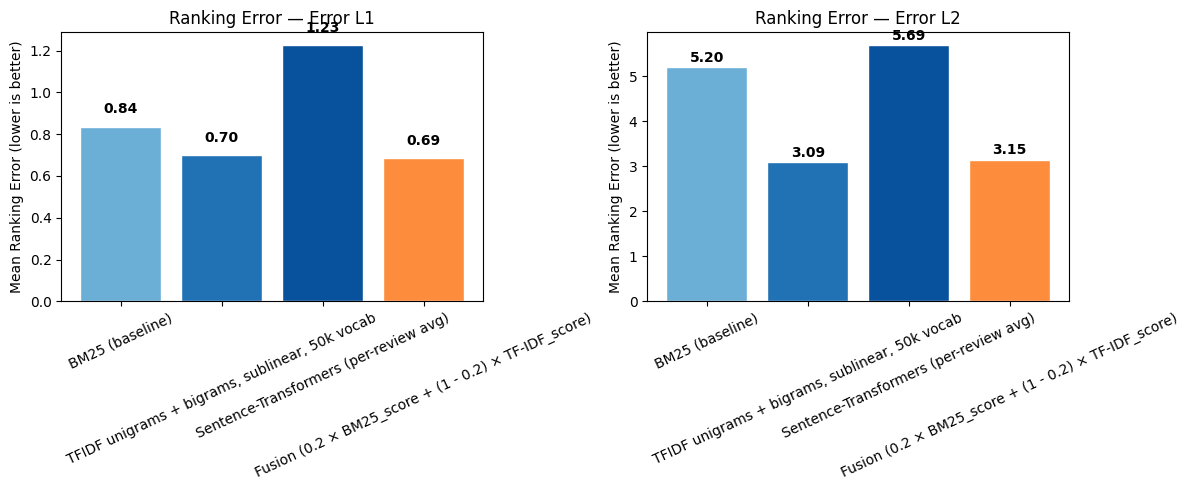

In [34]:
# Collect the best fusion result
best_fusion = min(fusion_results, key=lambda x: x["Error L2"])
best_TFIDF = min(result_dataset.to_dict('records'), key=lambda x: x["Error L2"])

final_results = pd.DataFrame([
    {"Model": "BM25 (baseline)","Error L1": round(bm25_L1, 4),  "Error L2": round(bm25_L2, 4)},
    best_TFIDF,
    {"Model": "Sentence-Transformers (per-review avg)","Error L1": round(st_L1, 4),    "Error L2": round(st_L2, 4)},
    best_fusion,
])

final_results.head(4)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#6baed6", "#2171b5", "#08519c", "#fd8d3c"]

for ax, metric in zip(axes, ["Error L1", "Error L2"]):
    bars = ax.bar(final_results["Model"], final_results[metric], color=colors, edgecolor="white")
    ax.set_ylabel("Mean Ranking Error (lower is better)")
    ax.set_title(f"Ranking Error — {metric}")
    ax.tick_params(axis="x", rotation=25)
    for bar, val in zip(bars, final_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### Conclusion

## 11. Best Model Pipeline

Know that we know which model is the best, we can create our pipeline with this model

In [ ]:
class Review_model:
    def __init__(self, data_path):
        self.data_path = data_path
        
        self.vectorizer = None
        self.train_embeddings = None
        self.train_df = None

        
        self.max_features = 50_000
        self.ngram_range = (1, 2)
        self.sublinear = True


                    ### Preprocessing function

    def clean_text_spacy(self, texts: list) -> list:
        """
        Lemmatization of a batch of texts using spaCy.
        """
        results = []
        # We use pip to disable the parser and ner module of our spacy model so that our code run faster
        for doc in nlp.pipe(texts, batch_size=256, disable=["parser", "ner"]):
            # We apply lemmatisation and keeps only alphabetic, non-stop tokens longer than 2 characters
            lemmas = [
                t.lemma_.lower()
                for t in doc
                if t.is_alpha and not t.is_stop and len(t) > 2
            ]
            # We put the text together again to have our review
            results.append(" ".join(lemmas))
        return results
    
    def aggregate_reviews(self, reviews):
        """
        Transform the pandas series into a list and only keep at most 50 reviews
        """
        reviews_texts = reviews["clean_review"].tolist()
        if MAX_REVIEWS_PER_PLACE:
            reviews_texts = reviews_texts[:MAX_REVIEWS_PER_PLACE]
        # Create one string containing the list of reviews
        return " ".join(reviews_texts)
    
    def preprocessing(self, reviews_dataset,metadata_dataset = None):
        reviews_dataset["clean_review"] = self.clean_text_spacy(reviews_dataset["review"].tolist())
        reviews_place = (
            reviews_dataset
            .groupby("idplace", group_keys=False)
            .apply(self.aggregate_reviews, include_groups=False)
            .reset_index()
            .rename(columns={"idplace": "place_id", 0: "reviews"})
            )
        
        if metadata_dataset is None:
            # When we don't have a label(For prediction)
            return reviews_place
        metadata_colums = [column for column in META_COLS if column in metadata_dataset.columns]

        # We get our evaluation column into our model dataset
        reviews_place = reviews_place.merge(
            metadata_dataset[metadata_colums].rename(columns={"id": "place_id"}),
            on="place_id",
            how="left",
            )
        return reviews_place

        
                        ### Model function function


    def get_ranked_indices_batch(self, train_matrix, test_matrix, batch_size: int = 200) -> np.ndarray:
        """
        Function that compute the cosine similarity for every values in the test matrix 
        compared to the train matrix
        Processes in batches
        """
        n_train  = train_matrix.shape[0]
        all_rank = []

    # We use the tqdm function to create a display of the process
    # The loop works in batch 
        for i in tqdm(range(0, n_train, batch_size), desc="Cosine Simularities Ranking"):
            # We calculate the batch that we will treat in this loop
            batch      = train_matrix[i : i + batch_size]
            # We calculate the cosine similarity
            sims_batch = (batch @ test_matrix.T).toarray()   # (batch, n_candidates)
            # We sort the rank in desending order
            rank       = np.argsort(sims_batch, axis=1)[:, ::-1] 
            all_rank.append(rank)

        # Make a vertical fusion of all value that are in all_rank
        return np.vstack(all_rank)
    
    def fit(self, train_data):
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=self.max_features, 
            ngram_range=self.ngram_range, 
            sublinear_tf=self.sublinear_tf
            )

        self.tfidf_vectorizer.fit(train_data["reviews"])
        self.train_embeddings = self.vectorizer.transform(train_data["reviews"])  

    def transform(self, data):
        test_matrix  = self.vectorizer.transform(data["reviews"])   
        tfidf_rankings = self.get_ranked_indices_batch(self.train_embeddings, test_matrix)

        return tfidf_rankings
    
    def train(self, reviews_dataset,metadata_dataset):
        self.train_df = self.preprocessing(reviews_dataset,metadata_dataset)
        self.fit(self.train_df)

    def predict_rank(self, reviews_dataset):
        review_place = self.preprocessing(reviews_dataset)
        ranking = self.transform(review_place)
        return ranking
    

    
